In [1]:
!pip install optuna catboost koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 92.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# 데이터 전처리(데이터 분리, 스케일링, 인코딩, 파이프라인(데이터 누수 방지)관련
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Base Models
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import NearestNeighbors
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, plot_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.svm import SVR

# Stacking
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Optuna 관련
import optuna
from optuna import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)
# Optuna 로깅 레벨 조절
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 랜덤 시드 고정
RANDOM_STATE = 42
N_SPLITS = 5
np.random.seed(RANDOM_STATE)

print(f"Optuna 버전: {optuna.__version__}")

def rmse(y_true, y_pred):
    return float(root_mean_squared_error(y_true, y_pred))

Optuna 버전: 4.7.0


In [3]:
# 데이터 로드 & 확인
# train 데이터
calories_data = pd.read_csv("/content/final_train_adj_v9.csv")
calories_data.columns = [c.strip() for c in calories_data.columns]    # 컬럼명 앞뒤 공백 제거

print(calories_data.shape)    # (7500, 12)
display(calories_data.info())

# 중복 데이터 확인
dup_rows = calories_data[calories_data.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")
print("중복 개수:", calories_data.duplicated().sum())

# 중복 샘플 드랍
calories_data = calories_data.drop_duplicates(keep="first")
print("남아있는 중복 개수:", calories_data.duplicated().sum())

(7500, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   body_temp                  7500 non-null   float64
 2   bpm                        7500 non-null   float64
 3   height_feet                7500 non-null   float64
 4   height_inche               7500 non-null   float64
 5   weight_lb                  7500 non-null   float64
 6   age                        7500 non-null   int64  
 7   bmi                        7500 non-null   float64
 8   bsa_intensity_time         7500 non-null   float64
 9   exercise_stress_index_raw  7500 non-null   float64
 10  weight_status              7500 non-null   object 
 11  gender                     7500 non-null   object 
 12  age_section                7500 non-null   object 
 13  bpm_section                7500 non-n

None

중복 확인:
      ex_dura  body_temp   bpm  height_feet  height_inche  weight_lb  age  \
4251      9.0      103.1  90.0          5.0           5.0      130.1   28   
4662      9.0      103.1  90.0          5.0           5.0      130.1   28   

        bmi  bsa_intensity_time  exercise_stress_index_raw  weight_status  \
4251  21.65            6.940287                   49.29503  Normal Weight   
4662  21.65            6.940287                   49.29503  Normal Weight   

     gender age_section bpm_section ex_section  calories_burned  
4251      F         20대         mid     ex_mid             40.0  
4662      F         20대         mid     ex_mid             40.0  
중복 개수: 1
남아있는 중복 개수: 0


In [4]:
# 데이터 분리
X = calories_data.drop(columns=['calories_burned']).copy()
y = calories_data['calories_burned'].copy()

# 범주형/수치형 자동 추정
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("cat_cols:", cat_cols)
print("num_cols:", num_cols[:10], "...")

# train, validation 분리
# 이상치 제이터 flag 정의
# 체온 >= 40이면 outlier_flag = 1
outlier_flag = (calories_data['body_temp'] >= 40).astype(int)

X_train, X_valid, y_train, y_valid, flag_train, flag_valid = train_test_split(
    X, y, outlier_flag, test_size=0.2, random_state=RANDOM_STATE, stratify=outlier_flag
)

# 분리된 형태 확인
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape, flag_train.shape, flag_valid.shape

cat_cols: ['weight_status', 'gender', 'age_section', 'bpm_section', 'ex_section']
num_cols: ['ex_dura', 'body_temp', 'bpm', 'height_feet', 'height_inche', 'weight_lb', 'age', 'bmi', 'bsa_intensity_time', 'exercise_stress_index_raw'] ...


((5999, 15), (1500, 15), (5999,), (1500,), (5999,), (1500,))

In [5]:
# 모델별 다른 전처리 정의

num_pipe_for_svr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

num_pipe_for_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_for_svr = ColumnTransformer(
    [("num", num_pipe_for_svr, num_cols),
     ("cat", cat_pipe, cat_cols)],
    remainder="drop"
)

preprocess_for_tree = ColumnTransformer(
    [("num", num_pipe_for_tree, num_cols),
     ("cat", cat_pipe, cat_cols)],
    remainder="drop"
)

In [6]:
# 잔차보정 스택킹 모델 생성 함수
def residual_stacking_cv_rmse(
    X, y,
    base_model,          # SVR pipeline
    residual_model,      # LGBM/XGB/ExtraTrees 등
    outer_splits=5,
    inner_splits=5,
    random_state=42
):
    outer = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    preds_all = pd.Series(index=X.index, dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(outer.split(X), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # ----- inner OOF로 base(SVR) 예측 만들어서 잔차 생성 -----
        inner = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)

        oof_base_tr = pd.Series(index=X_tr.index, dtype=float)

        for in_tr_idx, in_va_idx in inner.split(X_tr):
            X_in_tr, X_in_va = X_tr.iloc[in_tr_idx], X_tr.iloc[in_va_idx]
            y_in_tr = y_tr.iloc[in_tr_idx]

            m_base = clone(base_model)
            m_base.fit(X_in_tr, y_in_tr)
            oof_base_tr.loc[X_in_va.index] = m_base.predict(X_in_va)

        residual_tr = y_tr - oof_base_tr  # 잔차 (누설 없음)

        # ----- 잔차 모델 학습 (입력은 원래 X 그대로) -----
        m_res = clone(residual_model)
        m_res.fit(X_tr, residual_tr)

        # ----- outer fold에서 base는 전체 train으로 fit 후 valid 예측 -----
        m_base_full = clone(base_model)
        m_base_full.fit(X_tr, y_tr)
        pred_base_va = m_base_full.predict(X_va)

        # ----- valid에서 잔차 예측 -----
        pred_res_va = m_res.predict(X_va)

        # ----- 합산 -----
        preds_all.loc[X_va.index] = pred_base_va + pred_res_va

        print(f"[Outer Fold {fold}] RMSE:", rmse(y_va, preds_all.loc[X_va.index]))

    return rmse(y, preds_all.values), preds_all

In [ ]:
# 잔차모델: LGBM
res_lgbm = Pipeline([
    ("prep", preprocess_for_tree),
    ("model", LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    ))
])

# 잔차모델: XGB
res_xgb = Pipeline([
    ("prep", preprocess_for_tree),
    ("model", XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        tree_method="hist"
    ))
])

# 잔차모델: ExtraTrees
from sklearn.ensemble import ExtraTreesRegressor
res_extra = Pipeline([
    ("prep", preprocess_for_tree),
    ("model", ExtraTreesRegressor(
        n_estimators=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# base는 SVR
base_svr = Pipeline([
        ("prep", preprocess_for_svr),
        ("model", SVR(C=18000, gamma=0.0055, epsilon=0.019))
        ])

rmse_res_lgbm, _ = residual_stacking_cv_rmse(X, y, base_svr, res_lgbm, outer_splits=N_SPLITS, inner_splits=5, random_state=RANDOM_STATE)
print("\nResidual Stacking (SVR + LGBM-residual) RMSE:", rmse_res_lgbm)

rmse_res_xgb, _ = residual_stacking_cv_rmse(X, y, base_svr, res_xgb, outer_splits=N_SPLITS, inner_splits=5, random_state=RANDOM_STATE)
print("\nResidual Stacking (SVR + XGB-residual) RMSE:", rmse_res_xgb)

rmse_res_extra, _ = residual_stacking_cv_rmse(X, y, base_svr, res_extra, outer_splits=N_SPLITS, inner_splits=5, random_state=RANDOM_STATE)
print("\nResidual Stacking (SVR + ExtraTrees-residual) RMSE:", rmse_res_extra)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1081
[LightGBM] [Info] Number of data points in the train set: 5999, number of used features: 27
[LightGBM] [Info] Start training from score -0.002405
[Outer Fold 1] RMSE: 0.38391640350513434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1083
[LightGBM] [Info] Number of data points in the train set: 5999, number of used features: 27
[LightGBM] [Info] Start training from score -0.002381
[Outer Fold 2] RMSE: 0.3699582550066349
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000291 seconds.
You

In [ ]:
def lgbm_cv_rmse_with_early_stopping(trial, X, y, preprocess, n_splits=5, random_state=42):
    params = {
        "n_estimators": 20000,  # 크게 잡고 early stopping으로 자르기
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "random_state": random_state,
        "verbosity": -1,
    }

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rmses = []

    for tr_idx, va_idx in cv.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # preprocess fold fit
        prep = clone(preprocess)
        X_tr_t = prep.fit_transform(X_tr)
        X_va_t = prep.transform(X_va)

        model = LGBMRegressor(**params)
        model.fit(
            X_tr_t, y_tr,
            eval_set=[(X_va_t, y_va)],
            eval_metric="rmse",
            callbacks=[
                # early stopping
                __import__("lightgbm").early_stopping(stopping_rounds=200, verbose=False)
            ],
        )

        pred = model.predict(X_va_t)
        rmses.append(rmse(y_va, pred))

    return float(np.mean(rmses))

def objective_lgbm_es(trial):
    return lgbm_cv_rmse_with_early_stopping(trial, X, y, preprocess_for_tree, n_splits=N_SPLITS, random_state=RANDOM_STATE)

study_lgbm_es = optuna.create_study(direction="minimize")
study_lgbm_es.optimize(objective_lgbm_es, n_trials=30, show_progress_bar=True)

print("Best LGBM(early stopping) RMSE:", study_lgbm_es.best_value)
print("Best params:", study_lgbm_es.best_params)

In [ ]:
def make_oof_predictions(X, y, models, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = pd.DataFrame(index=X.index)
    fold_scores = {name: [] for name in models.keys()}

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        for name, model in models.items():
            m = clone(model)
            m.fit(X_tr, y_tr)
            pred = m.predict(X_va)
            oof.loc[X_va.index, f"pred_{name}"] = pred
            fold_scores[name].append(rmse(y_va, pred))

        print(f"[Fold {fold}] " + " | ".join([f"{k}: {fold_scores[k][-1]:.5f}" for k in models.keys()]))

    print("\n=== Base model OOF CV RMSE (subset) ===")
    for name in models.keys():
        print(f"{name}: {np.mean(fold_scores[name]):.5f} ± {np.std(fold_scores[name]):.5f}")

    return oof

oof_base_3 = make_oof_predictions(X, y, base_models_3, n_splits=N_SPLITS, random_state=RANDOM_STATE)
oof_base_3.head()

[Fold 1] svr: 0.33891 | lgbm: 1.22268 | xgb: 1.53354
[Fold 2] svr: 0.33763 | lgbm: 1.35067 | xgb: 1.43559
[Fold 3] svr: 0.33622 | lgbm: 1.28535 | xgb: 1.50034
[Fold 4] svr: 0.34668 | lgbm: 1.28154 | xgb: 1.52966
[Fold 5] svr: 0.34358 | lgbm: 1.22099 | xgb: 1.53724

=== Base model OOF CV RMSE (subset) ===
svr: 0.34060 ± 0.00392
lgbm: 1.27225 ± 0.04794
xgb: 1.50727 ± 0.03814


,pred_svr,pred_lgbm,pred_xgb
0,166.249377,167.947603,167.141998
1,33.159737,32.827038,33.091797
2,23.129511,23.650252,23.517166
3,91.320520,89.289615,89.165939
4,32.528115,32.554677,32.386265


In [ ]:
# 메타 피처 추가
def add_meta_features(pred_df: pd.DataFrame):
    out = pred_df.copy()
    pred_cols = [c for c in out.columns if c.startswith("pred_")]

    out["meta_mean"] = out[pred_cols].mean(axis=1)
    out["meta_std"]  = out[pred_cols].std(axis=1)
    out["meta_range"] = out[pred_cols].max(axis=1) - out[pred_cols].min(axis=1)

    # 차이 피처
    if "pred_svr" in out.columns and "pred_lgbm" in out.columns:
        out["meta_svr_minus_lgbm"] = out["pred_svr"] - out["pred_lgbm"]
    if "pred_svr" in out.columns and "pred_xgb" in out.columns:
        out["meta_svr_minus_xgb"] = out["pred_svr"] - out["pred_xgb"]

    return out

In [ ]:
# density 얻기(얼마나 외진 점인가?)

def make_oof_density_feature(X, models_any_preprocess, n_splits=5, random_state=42, k=15):
    """
    density = KNN 평균거리 (작을수록 밀집, 클수록 희귀/외곽)
    누설 방지 위해 fold마다 train으로 전처리-fit 후, valid transform에 대해 train 공간에서 KNN 거리 계산
    """
    # 전처리만 쓰기 위해 임의의 모델 하나에서 prep만 뽑아 사용
    # (여기서는 SVR 파이프의 prep을 사용)
    prep = models_any_preprocess["svr"].named_steps["prep"]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    dens = pd.Series(index=X.index, dtype=float)

    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]

        prep_fold = clone(prep)
        X_tr_t = prep_fold.fit_transform(X_tr)
        X_va_t = prep_fold.transform(X_va)

        nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
        nn.fit(X_tr_t)

        dists, _ = nn.kneighbors(X_va_t, return_distance=True)
        dens.loc[X_va.index] = dists.mean(axis=1)

    return dens

In [ ]:
# 메타 학습용 데이터 완성
oof_full = add_meta_features(oof_base_3)
oof_full["meta_density"] = make_oof_density_feature(X, base_models_3, n_splits=N_SPLITS, random_state=RANDOM_STATE, k=15)

oof_full.head()

,pred_svr,pred_lgbm,pred_xgb,meta_mean,meta_std,meta_range,meta_svr_minus_lgbm,meta_svr_minus_xgb,meta_density
0,166.249377,167.947603,167.141998,167.112993,0.849485,1.698226,-1.698226,-0.892621,0.902980
1,33.159737,32.827038,33.091797,33.026191,0.175785,0.332699,0.332699,0.067940,1.025635
2,23.129511,23.650252,23.517166,23.432310,0.270542,0.520741,-0.520741,-0.387655,1.103482
3,91.320520,89.289615,89.165939,89.925358,1.209827,2.154580,2.030904,2.154580,0.968470
4,32.528115,32.554677,32.386265,32.489686,0.090544,0.168412,-0.026562,0.141850,0.987320


In [ ]:
# 메타 모델 학습(Ridge 버전)
meta_X_3 = oof_full.copy()
meta_y = y.copy()

kf_meta = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Ridge
meta_ridge = Ridge(alpha=60, random_state=RANDOM_STATE)
pred_stack_ridge_3 = cross_val_predict(meta_ridge, meta_X_3, meta_y, cv=kf_meta, n_jobs=-1)
print("Stacking(3models, Meta=Ridge) RMSE:", rmse(meta_y, pred_stack_ridge_3))

# Positive Linear (권장)
meta_pos = LinearRegression(positive=True)
pred_stack_pos_3 = cross_val_predict(meta_pos, meta_X_3, meta_y, cv=kf_meta, n_jobs=-1)
print("Stacking(3models, Meta=PositiveLR) RMSE:", rmse(meta_y, pred_stack_pos_3))

Stacking(3models, Meta=Ridge) RMSE: 0.34112140413618125
Stacking(3models, Meta=PositiveLR) RMSE: 0.3410521995143558


# Optuna를 통한 하이퍼파라미터 최적화

In [ ]:
# Ridge 튜닝
def objective_meta_ridge(trial):
    alpha = trial.suggest_float("alpha", 50, 70, log=True)
    model = Ridge(alpha=alpha, random_state=RANDOM_STATE)

    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pred = cross_val_predict(model, meta_X_3, meta_y, cv=cv, n_jobs=-1)
    return rmse(meta_y, pred)

study_meta_ridge = optuna.create_study(direction="minimize")
study_meta_ridge.optimize(objective_meta_ridge, n_trials=50, show_progress_bar=True)

print("Best Meta Ridge RMSE:", study_meta_ridge.best_value)
print("Best params:", study_meta_ridge.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best Meta Ridge RMSE: 0.3411214013699148
Best params: {'alpha': 61.10558278493366}


# 최적화된 모델 평가

# Base Models 개별 성능 분석

In [ ]:
def residual_correlation(oof_base: pd.DataFrame, y: pd.Series):
    pred_cols = [c for c in oof_base.columns if c.startswith("pred_")]
    res = pd.DataFrame(index=oof_base.index)

    for c in pred_cols:
        res[c.replace("pred_", "res_")] = y.values - oof_base[c].values

    corr = res.corr()
    return res, corr

residuals_df, residual_corr = residual_correlation(oof_base_3, y)
residual_corr

# 해석
# res_*끼리 상관이 1에 가까우면 → “거의 같은 샘플에서 같은 방식으로 틀림” → stacking 이득 작아짐
# 상관이 낮거나 음수면 → “서로 다른 샘플/다른 방향으로 틀림” → stacking 이득 커짐

,res_svr,res_lgbm,res_xgb
res_svr,1.000000,0.262822,0.206784
res_lgbm,0.262822,1.000000,0.548340
res_xgb,0.206784,0.548340,1.000000


In [ ]:
def top_error_overlap(oof_base: pd.DataFrame, y: pd.Series, top_frac=0.1):
    pred_cols = [c for c in oof_base.columns if c.startswith("pred_")]
    errs = {}
    for c in pred_cols:
        errs[c] = np.abs(y.values - oof_base[c].values)

    top_sets = {}
    n_top = int(len(y) * top_frac)

    for c in pred_cols:
        idx = np.argsort(errs[c])[-n_top:]  # 큰 오차 top
        top_sets[c] = set(oof_base.index[idx])

    # pairwise overlap (Jaccard)
    rows = []
    cols = pred_cols
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            a, b = cols[i], cols[j]
            inter = len(top_sets[a] & top_sets[b])
            union = len(top_sets[a] | top_sets[b])
            jacc = inter / union if union else np.nan
            rows.append((a, b, jacc, inter, union))
    out = pd.DataFrame(rows, columns=["model_a","model_b","jaccard","intersection","union"])
    return out.sort_values("jaccard", ascending=False)

overlap_df = top_error_overlap(oof_base_3, y, top_frac=0.1)
overlap_df.head(20)

# 해석
# jaccard가 높을수록 → “큰 오차 샘플이 서로 겹침” → 다양성 낮음
# 낮으면 → 서로 다른 구간을 놓침 → stacking 이득 가능

,model_a,model_b,jaccard,intersection,union
2,pred_lgbm,pred_xgb,0.256711,306,1192
0,pred_svr,pred_lgbm,0.083936,116,1382
1,pred_svr,pred_xgb,0.074605,104,1394


In [ ]:
# “오차 순위” 상관(Spearman)
from scipy.stats import spearmanr

def error_rank_spearman(oof_base: pd.DataFrame, y: pd.Series):
    pred_cols = [c for c in oof_base.columns if c.startswith("pred_")]
    err = pd.DataFrame(index=oof_base.index)
    for c in pred_cols:
        err[c] = np.abs(y.values - oof_base[c].values)

    # pairwise spearman
    rows = []
    for i in range(len(pred_cols)):
        for j in range(i+1, len(pred_cols)):
            a, b = pred_cols[i], pred_cols[j]
            r, _ = spearmanr(err[a], err[b])
            rows.append((a, b, r))
    return pd.DataFrame(rows, columns=["model_a","model_b","spearman"]).sort_values("spearman", ascending=False)

spearman_df = error_rank_spearman(oof_base_3, y)
spearman_df.head(20)

,model_a,model_b,spearman
2,pred_lgbm,pred_xgb,0.307954
0,pred_svr,pred_lgbm,0.076137
1,pred_svr,pred_xgb,0.050063


In [ ]:
def describe_density(oof_full: pd.DataFrame, col="meta_density"):
    s = oof_full[col].dropna()
    desc = s.describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99])
    return desc

describe_density(oof_full, "meta_density")

# 여기서 0.95~0.99 분위 값이 확 튀면 “외곽 점”들이 분리되는 신호

,meta_density
count,7499.000000
mean,1.200773
std,0.362992
min,0.580908
1%,0.657431
5%,0.732730
10%,0.787581
25%,0.919028
50%,1.129393
75%,1.432461


In [ ]:
# density와 오차의 관계(상관 + 구간별 RMSE)
# density vs 절대오차 상관
def density_error_relation(oof_base: pd.DataFrame, oof_full: pd.DataFrame, y: pd.Series, model="svr"):
    pred_col = f"pred_{model}"
    abs_err = np.abs(y.values - oof_base[pred_col].values)
    dens = oof_full["meta_density"].values

    pearson = np.corrcoef(dens, abs_err)[0,1]
    spearman = spearmanr(dens, abs_err).correlation
    return pearson, spearman

pearson, spearman = density_error_relation(oof_base_3, oof_full, y, model="svr")
print("density vs |error| (SVR) pearson:", pearson)
print("density vs |error| (SVR) spearman:", spearman)
# 해석: spearman이 양수로 꽤 크면 → 밀집 낮은(희귀) 구간에서 오차 증가 경향.

# density 분위(bin)별 모델 RMSE 비교

def rmse_by_density_bins(oof_base: pd.DataFrame, oof_full: pd.DataFrame, y: pd.Series, n_bins=10):
    df = pd.DataFrame(index=oof_base.index)
    df["density"] = oof_full["meta_density"]
    df["y"] = y
    pred_cols = [c for c in oof_base.columns if c.startswith("pred_")]
    for c in pred_cols:
        df[c] = oof_base[c]

    df["bin"] = pd.qcut(df["density"], q=n_bins, labels=False, duplicates="drop")

    rows = []
    for b in sorted(df["bin"].dropna().unique()):
        chunk = df[df["bin"] == b]
        row = {"bin": int(b), "n": len(chunk), "density_mean": float(chunk["density"].mean())}
        for c in pred_cols:
            row[c.replace("pred_","rmse_")] = rmse(chunk["y"], chunk[c])
        rows.append(row)

    out = pd.DataFrame(rows).sort_values("bin")
    return out

bin_rmse = rmse_by_density_bins(oof_base_3, oof_full, y, n_bins=10)
print(bin_rmse)

# 해석
# density가 큰 bin(희귀)에서 SVR rmse가 유독 나빠지고, 트리 쪽 rmse가 덜 나빠지면 → “희귀영역 보완” 구조가 살아있음
# 반대로 모든 모델이 같이 무너진다면 → density가 희귀를 잡긴 하지만 “해결책 모델”이 없는 상태

density vs |error| (SVR) pearson: 0.13214795199388008
density vs |error| (SVR) spearman: 0.07044844800681346
   bin    n  density_mean  rmse_svr  rmse_lgbm  rmse_xgb
0    0  750      0.725228  0.306312   0.841602  1.001607
1    1  750      0.834811  0.308610   0.922055  1.088143
2    2  750      0.918801  0.319467   0.968648  1.167170
3    3  750      0.997015  0.305380   1.081560  1.218939
4    4  750      1.084530  0.327053   1.135560  1.514027
5    5  749      1.182198  0.327947   1.175459  1.414492
6    6  750      1.295888  0.345405   1.355107  1.670232
7    7  750      1.433476  0.348773   1.327058  1.518933
8    8  750      1.606565  0.365537   1.598521  1.873483
9    9  750      1.929195  0.432190   1.928366  2.190345


In [ ]:
# “희귀 상위 x%”에서 모델 랭킹 비교
def model_rank_in_rare_region(oof_base: pd.DataFrame, oof_full: pd.DataFrame, y: pd.Series, top_frac=0.05):
    df = oof_base.copy()
    df["density"] = oof_full["meta_density"]
    df["y"] = y

    thr = df["density"].quantile(1 - top_frac)
    rare = df[df["density"] >= thr]

    pred_cols = [c for c in oof_base.columns if c.startswith("pred_")]
    scores = []
    for c in pred_cols:
        scores.append((c, rmse(rare["y"], rare[c]), len(rare)))
    out = pd.DataFrame(scores, columns=["model","rmse_in_rare","n"]).sort_values("rmse_in_rare")
    return thr, out

thr, rare_rank = model_rank_in_rare_region(oof_base_3, oof_full, y, top_frac=0.05)
print("rare density threshold (top 5%):", thr)
rare_rank

rare density threshold (top 5%): 1.8603452493199202


,model,rmse_in_rare,n
0,pred_svr,0.465909,375
1,pred_lgbm,2.316832,375
2,pred_xgb,2.488052,375


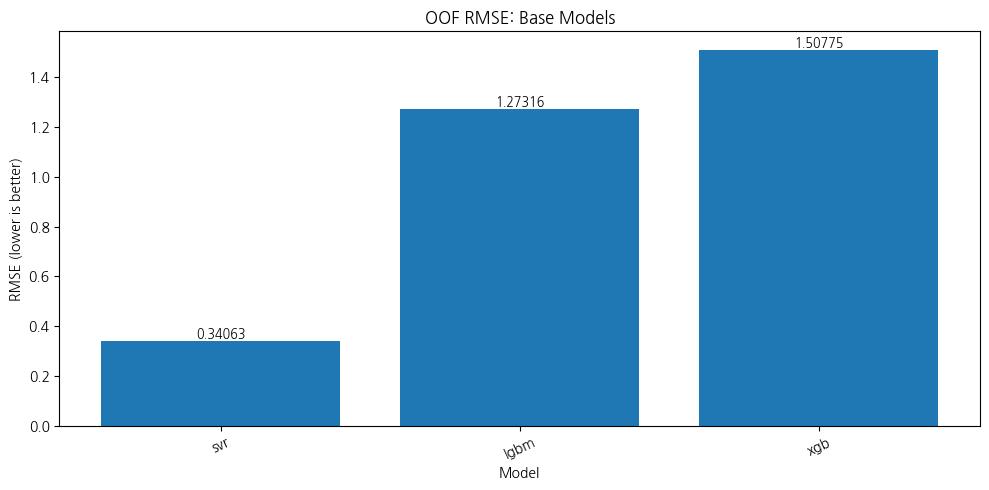

In [ ]:
# Base Models vs Stacking 시각화
def get_base_rmse_table(oof_base: pd.DataFrame, y: pd.Series):
    pred_cols = [c for c in oof_base.columns if c.startswith("pred_")]
    rows = []
    for c in pred_cols:
        rows.append({
            "model": c.replace("pred_", ""),
            "rmse": rmse(y, oof_base[c])
        })
    out = pd.DataFrame(rows).sort_values("rmse", ascending=True).reset_index(drop=True)
    return out

def plot_rmse_bar(df_rmse: pd.DataFrame, title="OOF RMSE: Base Models"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(df_rmse["model"], df_rmse["rmse"])
    ax.set_title(title)
    ax.set_ylabel("RMSE (lower is better)")
    ax.set_xlabel("Model")
    ax.tick_params(axis='x', rotation=25)

    # 값 라벨
    for i, v in enumerate(df_rmse["rmse"].values):
        ax.text(i, v, f"{v:.5f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

base_rmse_df = get_base_rmse_table(oof_base_3, y)
base_rmse_df
plot_rmse_bar(base_rmse_df, title="OOF RMSE: Base Models")

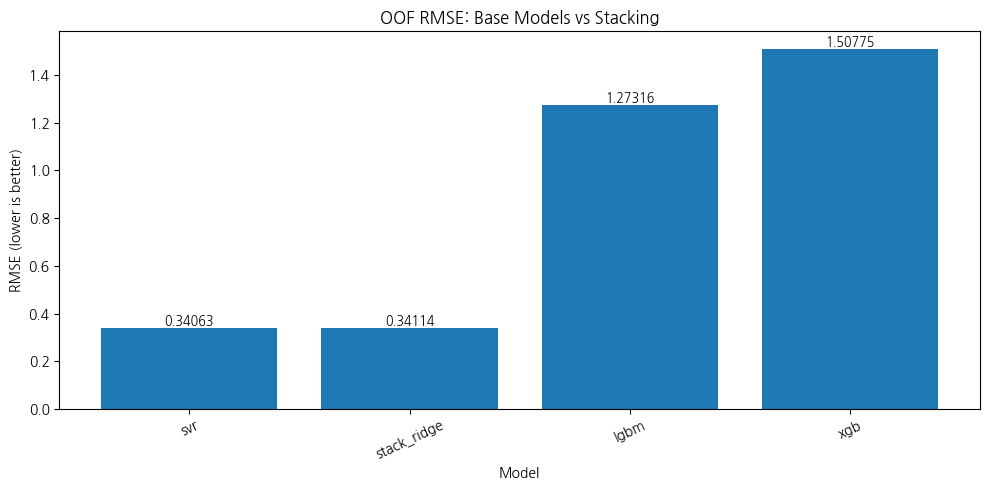

In [ ]:
# “메타 모델 CV 예측”으로 stacking RMSE 계산
def stacking_cv_rmse(meta_X: pd.DataFrame, meta_y: pd.Series, meta_model):
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pred = cross_val_predict(meta_model, meta_X, meta_y, cv=cv, n_jobs=-1)
    return rmse(meta_y, pred)

# 베이스 vs. 메타 비교
def make_comparison_table(oof_base: pd.DataFrame, y: pd.Series, stacking_results: dict):
    """
    stacking_results 예시:
    {
      "stack_ridge": 0.1234,
      "stack_tree": 0.1220,
    }
    """
    base_df = get_base_rmse_table(oof_base, y)
    rows = base_df.to_dict("records")
    for name, score in stacking_results.items():
        rows.append({"model": name, "rmse": float(score)})

    out = pd.DataFrame(rows).sort_values("rmse", ascending=True).reset_index(drop=True)
    return out

# 1) Ridge meta
ridge_meta = Ridge(alpha=1.0, random_state=RANDOM_STATE)
rmse_stack_ridge = stacking_cv_rmse(meta_X_3, meta_y, ridge_meta)

stacking_results = {"stack_ridge": rmse_stack_ridge}

# 2) (선택) 트리 meta를 쓰는 경우: 이미 meta_model_tree(LGBMRegressor 등)가 있으면 아래처럼 추가
# stacking_results["stack_tree"] = stacking_cv_rmse(meta_X, meta_y, meta_model_tree)

compare_df = make_comparison_table(oof_base_3, y, stacking_results)
compare_df
plot_rmse_bar(compare_df, title="OOF RMSE: Base Models vs Stacking")

In [ ]:
# “각 Fold에서” Base vs Stacking 성능 변화 라인 플롯
def fold_rmse_table_for_base_and_stacking(X, y, base_models: dict, meta_builder_fn, meta_model):
    """
    meta_builder_fn: fold에서 만든 oof_pred_df -> meta feature df로 변환하는 함수
    base_models: {name: pipeline}
    """
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pred_names = list(base_models.keys())

    rows = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # base fold preds
        fold_pred = pd.DataFrame(index=X_va.index)
        for name in pred_names:
            m = base_models[name]
            m.fit(X_tr, y_tr)
            fold_pred[f"pred_{name}"] = m.predict(X_va)

        # base RMSE
        fold_row = {"fold": fold}
        for name in pred_names:
            fold_row[f"rmse_{name}"] = rmse(y_va, fold_pred[f"pred_{name}"])

        # stacking (meta train on tr: need OOF on tr to be strict)
        # 간단/빠른 버전: meta는 tr에서 base full-fit 예측을 쓰면 누설 리스크가 있음.
        # 여기서는 "정석"으로: tr 내부에서 OOF를 한 번 더 만들어 meta를 학습한 뒤 va에 적용.

        inner_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

        # inner OOF for meta training
        tr_oof = pd.DataFrame(index=X_tr.index)
        for name in pred_names:
            tr_oof[f"pred_{name}"] = np.nan

        for in_tr_idx, in_va_idx in inner_cv.split(X_tr):
            X_in_tr, X_in_va = X_tr.iloc[in_tr_idx], X_tr.iloc[in_va_idx]
            y_in_tr = y_tr.iloc[in_tr_idx]

            for name in pred_names:
                m = base_models[name]
                m.fit(X_in_tr, y_in_tr)
                tr_oof.loc[X_in_va.index, f"pred_{name}"] = m.predict(X_in_va)

        meta_tr_X = meta_builder_fn(tr_oof)
        meta_tr_y = y_tr

        # meta fit
        meta_model.fit(meta_tr_X, meta_tr_y)

        # meta predict on outer va
        meta_va_X = meta_builder_fn(fold_pred)
        stack_pred = meta_model.predict(meta_va_X)
        fold_row["rmse_stacking"] = rmse(y_va, stack_pred)

        rows.append(fold_row)

    return pd.DataFrame(rows)

# meta feature builder
def meta_builder(df_pred):
    return add_meta_features(df_pred)

# base_models, X, y 가 이미 있는 상태라고 가정
fold_df = fold_rmse_table_for_base_and_stacking(X, y, base_models_3, meta_builder, Ridge(alpha=1.0, random_state=RANDOM_STATE))
print(fold_df.head())

def plot_fold_rmse_lines(fold_df: pd.DataFrame, title="Fold RMSE: Base vs Stacking"):
    x = fold_df["fold"].values

    fig, ax = plt.subplots(figsize=(10, 5))

    # base lines
    base_cols = [c for c in fold_df.columns if c.startswith("rmse_") and c != "rmse_stacking"]
    for c in base_cols:
        ax.plot(x, fold_df[c].values, marker="o", label=c.replace("rmse_", ""))

    # stacking line
    if "rmse_stacking" in fold_df.columns:
        ax.plot(x, fold_df["rmse_stacking"].values, marker="o", linewidth=3, label="stacking")

    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel("RMSE")
    ax.set_xticks(x)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_fold_rmse_lines(fold_df, title="Fold RMSE: Base Models vs Stacking (Meta=Ridge)")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:
# “희귀 영역(density bin)”에서 Base vs Stacking 비교 시각화
def plot_rmse_by_density_bins_base_vs_stacking(oof_base, oof_full, y, stacking_pred=None, n_bins=10):
    """
    stacking_pred: OOF stacking 예측(Series/ndarray). 없으면 base만 그림.
    """
    df = pd.DataFrame(index=oof_base.index)
    df["density"] = oof_full["meta_density"]
    df["y"] = y

    pred_cols = [c for c in oof_base.columns if c.startswith("pred_")]
    for c in pred_cols:
        df[c] = oof_base[c]

    if stacking_pred is not None:
        df["pred_stacking"] = stacking_pred

    df["bin"] = pd.qcut(df["density"], q=n_bins, labels=False, duplicates="drop")

    bins = sorted(df["bin"].dropna().unique())
    x = np.array(bins)

    # 각 bin의 RMSE 계산
    model_rmse = {}
    for c in pred_cols:
        vals = []
        for b in bins:
            chunk = df[df["bin"] == b]
            vals.append(rmse(chunk["y"], chunk[c]))
        model_rmse[c.replace("pred_", "")] = np.array(vals)

    if stacking_pred is not None:
        vals = []
        for b in bins:
            chunk = df[df["bin"] == b]
            vals.append(rmse(chunk["y"], chunk["pred_stacking"]))
        model_rmse["stacking"] = np.array(vals)

    # plot
    fig, ax = plt.subplots(figsize=(10, 5))
    for name, vals in model_rmse.items():
        ax.plot(x, vals, marker="o", label=name)

    ax.set_title("RMSE by Density Bin (higher bin ~ rarer region)")
    ax.set_xlabel("Density bin (0=most dense, higher=rarer)")
    ax.set_ylabel("RMSE")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_rmse_by_density_bins_base_vs_stacking(oof_base_3, oof_full, y, stacking_pred=pred_stack_ridge_3, n_bins=10)

# 테스트 데이터 예측

In [ ]:
def fit_full_and_predict(X_train, y_train, X_test, base_models, meta_model, k_density=15):
    # 1) base full fit
    fitted = {}
    base_test_preds = pd.DataFrame(index=X_test.index)

    for name, model in base_models.items():
        m = clone(model)
        m.fit(X_train, y_train)
        fitted[name] = m
        base_test_preds[f"pred_{name}"] = m.predict(X_test)

    # 2) meta feature for test (disagreement)
    test_meta = add_meta_features(base_test_preds)

    # 3) density for test: train 공간에서 KNN 거리
    prep = fitted["svr"].named_steps["prep"]
    Xtr_t = prep.transform(X_train)  # 이미 fit된 prep이므로 transform
    Xte_t = prep.transform(X_test)

    nn = NearestNeighbors(n_neighbors=k_density, metric="euclidean")
    nn.fit(Xtr_t)
    dists, _ = nn.kneighbors(Xte_t, return_distance=True)
    test_meta["meta_density"] = dists.mean(axis=1)

    # 4) meta model fit (메타는 OOF로 만든 meta_X로 학습해야 정석)
    #    -> 실전 제출용은 meta_model을 meta_X 전체에 fit 후 사용
    meta_model_fitted = clone(meta_model).fit(meta_X_3, meta_y)

    # 5) final predict
    final_pred = meta_model_fitted.predict(test_meta)
    return final_pred, base_test_preds, test_meta

# X_test 넣고 실행
# final_pred_ridge, base_test_preds, test_meta = fit_full_and_predict(X, y, X_test, base_models, meta_model_ridge)
# final_pred_tree,  _, _ = fit_full_and_predict(X, y, X_test, base_models, meta_model_tree)

In [ ]:
# 체크 포인트(성능이 안 오르면 여기부터 의심)
# 1. base 모델들이 서로 비슷하게 맞추면(meta_std 낮음) stacking 이득이 작음
# 2. SVR 파라미터(C/gamma/epsilon)와 전처리(특히 스케일링/결측)가 base 성능을 좌우
# 3. meta_density가 “희귀 영역”을 제대로 잡는지(분포 확인)
# 4. 트리 메타는 depth를 늘리는 순간 과적합으로 흔들릴 확률 ↑